<a href="https://colab.research.google.com/github/sg599/DL_Intel_Image_Classification_Block3_2026/blob/main/Assignment_Intel__Image_classification_Starting_Code_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import libraries

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix , classification_report
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

# From here, add any libraries that you might need for the rest of your code
import random
import numpy as np
from tensorflow.keras import layers, Model
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [2]:
if not os.path.exists("/content/seg_train/seg_train"):
    print("Dataset not found. Downloading...")

    !pip install -q kaggle

    from google.colab import files
    files.upload()

    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

    !kaggle datasets download -d puneet6060/intel-image-classification
    !unzip -o intel-image-classification.zip

    print("Download complete!")
else:
    print("Dataset already exists.")

Dataset not found. Downloading...


Streaminguitvoer ingekort tot de laatste 5000 regels.
  inflating: seg_train/seg_train/mountain/7537.jpg  
  inflating: seg_train/seg_train/mountain/7539.jpg  
  inflating: seg_train/seg_train/mountain/7551.jpg  
  inflating: seg_train/seg_train/mountain/7560.jpg  
  inflating: seg_train/seg_train/mountain/7565.jpg  
  inflating: seg_train/seg_train/mountain/7578.jpg  
  inflating: seg_train/seg_train/mountain/7581.jpg  
  inflating: seg_train/seg_train/mountain/7586.jpg  
  inflating: seg_train/seg_train/mountain/7647.jpg  
  inflating: seg_train/seg_train/mountain/7652.jpg  
  inflating: seg_train/seg_train/mountain/7654.jpg  
  inflating: seg_train/seg_train/mountain/7662.jpg  
  inflating: seg_train/seg_train/mountain/767.jpg  
  inflating: seg_train/seg_train/mountain/7672.jpg  
  inflating: seg_train/seg_train/mountain/7679.jpg  
  inflating: seg_train/seg_train/mountain/7681.jpg  
  inflating: seg_train/seg_train/mountain/7693.jpg  
  inflating: seg_train/seg_train/mountain/7695

# 2. Load and pre-process the dataset

In [3]:
# IF YOU USE GOOGLE COLAB AND HAVE THE DATA STORED ON YOUR GOOGLE DRIVE:
# from google.colab import drive
# drive.mount('/content/drive/') # mounts your Google Drive

In [4]:
# SET THE PATHS BASED ON WHERE YOU STORED THE DATASET:

# IF YOU USE GOOGLE COLAB AND HAVE THE DATA STORED ON YOUR GOOGLE DRIVE:
# !cp -r "/content/drive/MyDrive/Deep Learning/seg_train/seg_train" /content/ # copies the data from your Google Drive to colab's VM (may take a few mins; set path to your Google directory).
dataset_dir = "/content/seg_train/seg_train" # points to the local copy on colab's virtual machine (VM)

# IF YOU USE YOUR OWN COMPUTER:

# LIST THE CLASSES THAT EXIST WITHIN THIS DATASET:
CLASS_LABELS  = ['buildings', 'forest','glacier','mountain','sea','street'] # creates a list of the 6 classes in this dataset (the dataset contains images of 6 types of landscapes)


In [5]:
## IMPORTANT: please remember that you are not allowed to change the
## loading and preprocessing code to improve model performance for this assignment.

# LOAD AND PREPROCESS THE DATA:

# set size of images (in pixels) after resizing
IMG_HEIGHT = 42
IMG_WIDTH = 42

# set batch size
BATCH_SIZE = 128

# set relative sizes of the test and val set
TEST_SIZE = 0.2   # 20% of all x images will be used for testing the model
VAL_SIZE = 0.2    # of the remaining images, 20% will be used for validation and 80% for training

# function for adding noise to the images
def add_noise(img):
    std_coeff = 20 * np.random.random()
    noise = np.random.normal(0, std_coeff, img.shape)
    img += noise
    img = np.clip(img, 0., 255.)
    return img

# build dataframe with file paths and labels
all_files = []
all_labels = []

for class_name in sorted(os.listdir(dataset_dir)):
    class_path = os.path.join(dataset_dir, class_name)
    if os.path.isdir(class_path):
        for fname in os.listdir(class_path):
            fpath = os.path.join(class_path, fname)
            all_files.append(fpath)
            all_labels.append(class_name)

df = pd.DataFrame({"filename": all_files, "class": all_labels})

# split the data into train / val / test
trainval_df, test_df = train_test_split(df, test_size=TEST_SIZE, stratify=df["class"], random_state=31) # split all data into trainval + test
train_df, val_df   = train_test_split(trainval_df, test_size=VAL_SIZE, stratify=trainval_df["class"], random_state=31)  # split trainval data into train + val

# define generators
train_datagen = ImageDataGenerator(rescale=1./255, preprocessing_function=add_noise) # note: noise is only added to the train samples.
val_test_datagen = ImageDataGenerator(rescale=1./255)

# apply generators
train_data = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=7
)

val_data = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=7
)

test_data = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="class",
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("Data loading completed successfully.")
print(f"Number of training samples: {train_data.samples}")
print(f"Number of validation samples: {val_data.samples}")
print(f"Number of test samples: {test_data.samples}")
print(f"Class names: {train_data.class_indices}")

Found 8981 validated image filenames belonging to 6 classes.
Found 2246 validated image filenames belonging to 6 classes.
Found 2807 validated image filenames belonging to 6 classes.
Data loading completed successfully.
Number of training samples: 8981
Number of validation samples: 2246
Number of test samples: 2807
Class names: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


# 3. Visualise data and plot data distribution

In [6]:
#If you want to visualize the images in their real sizes, you can create a new dataloader and remove the resizing argument as shown below.
#If you want to visualize the images in their resized sizes, you can use the datalaoder as shown in the previous cells.

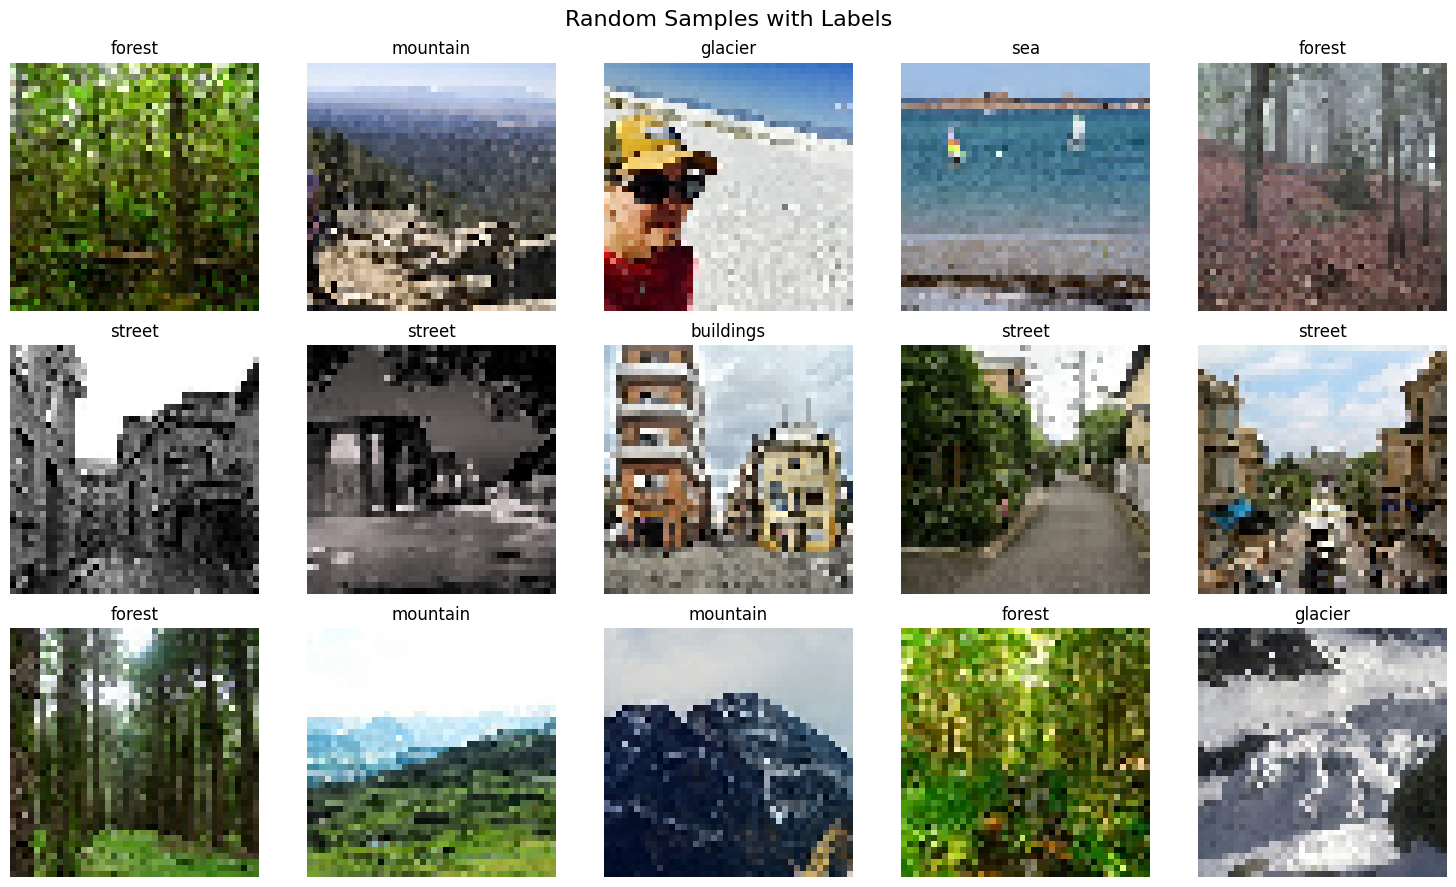

In [7]:
# SOFIA: TASK 1.PART I: 15 SAMPLES WITH LABELS

# df with 15 random samples
rnd_samples = train_df.sample(n = 15, random_state = 123)

plt.figure(figsize=(15, 9))
for i,(_,row) in enumerate(rnd_samples.iterrows()):
  file_path = row["filename"]
  class_label = row["class"]
  img = tf.keras.utils.load_img(file_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
  image_array = tf.keras.utils.img_to_array(img)/255.0

  plt.subplot(3, 5, i+1)
  plt.imshow(image_array)
  plt.title(class_label)
  plt.axis("off")

plt.suptitle("Random Samples with Labels", fontsize=16)
plt.tight_layout()
plt.show()

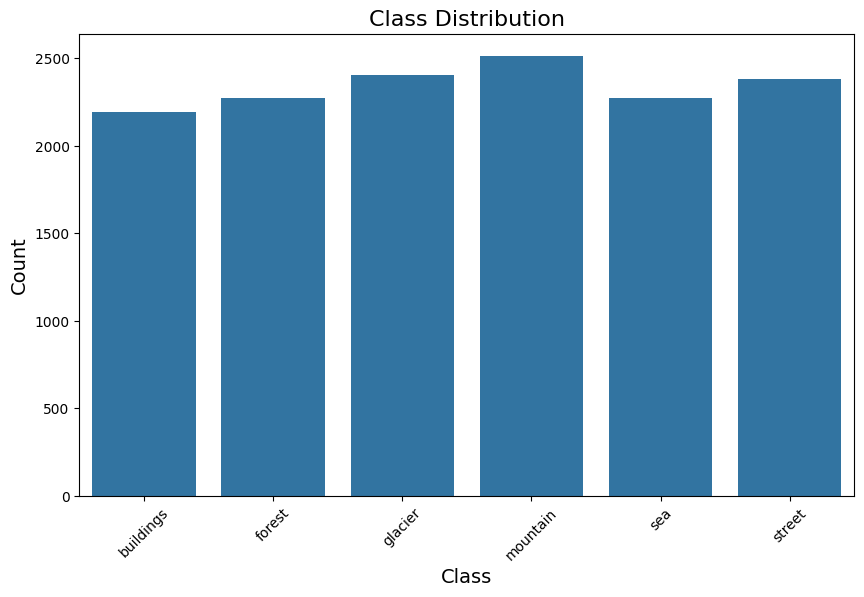

In [8]:
#   SOFIA: TASK 1. PART II. PLOT CLASS DISTRIBUTION
plt.figure(figsize=(10, 6))
sns.countplot(data = df, x = "class", order = CLASS_LABELS)
plt.title("Class Distribution", fontsize=16)
plt.xlabel("Class", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout
plt.show()

# 4. Model Design and Train and Evaluation functions

In [9]:
#   LAURA: TASK 2. PART I. BASELINE MODEL

# define input
inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

## 3 convolution blocks
#1
x = layers.Conv2D(16, (3, 3), activation='relu')(inputs)
x = layers.MaxPooling2D((2, 2))(x)
#2
x = layers.Conv2D(24, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
#3
x = layers.Conv2D(48, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)

# dense layers
x = layers.Flatten()(x)
x = layers.Dense(1200, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dense(6, activation='softmax')(x)

# define model
model = Model(inputs=inputs, outputs=x)

# compiling model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# display model
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 42, 42, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 40, 40, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 20, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 18, 18, 24)     │         3,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 9, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 48)       │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 432)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1200)           │       519,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       153,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 688,446 (2.63 MB)

 Trainable params: 688,446 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
#   LAURA: TASK 2. PART II. TRAINING BASELINE MODEL
history = model.fit(train_data, epochs=15, batch_size=64, validation_data= val_data)

Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 22s 172ms/step - accuracy: 0.3686 - loss: 1.5161 - val_accuracy: 0.5294 - val_loss: 1.1849
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step - accuracy: 0.5713 - loss: 1.1051 - val_accuracy: 0.6153 - val_loss: 0.9864
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step - accuracy: 0.6221 - loss: 0.9591 - val_accuracy: 0.6799 - val_loss: 0.8663
Epoch 4/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - accuracy: 0.6727 - loss: 0.8620 - val_accuracy: 0.6963 - val_loss: 0.8113
Epoch 5/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 121ms/step - accuracy: 0.6892 - loss: 0.8222 - val_accuracy: 0.7266 - val_loss: 0.7464
Epoch 6/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step - accuracy: 0.7284 - loss: 0.7213 - val_accuracy: 0.7333 - val_loss: 0.7303
Epoch 7/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - accuracy: 0.7375 - loss: 0.7080 - val_accuracy: 0.7213 - val_loss: 0.7728
Epoch 8/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 0.7594 - loss: 0.6591 - val_accuracy: 0

In [11]:
#   LAURA: TASK 2. PART III. BASELINE MODEL PLOTS AND METRICS

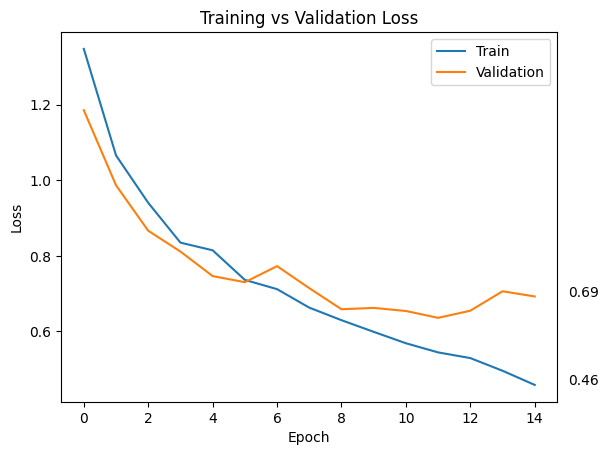

In [12]:
# train vs validation loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

# Part 3 Joyce: I found this on stackoverflow to show the numbers at the end
for var in (history.history['loss'], history.history['val_loss']):
  plt.annotate('%0.2f' % var[-1], xy=(1, var[-1]), xytext=(8, 0),
               xycoords=('axes fraction', 'data'), textcoords='offset points')

plt.show()

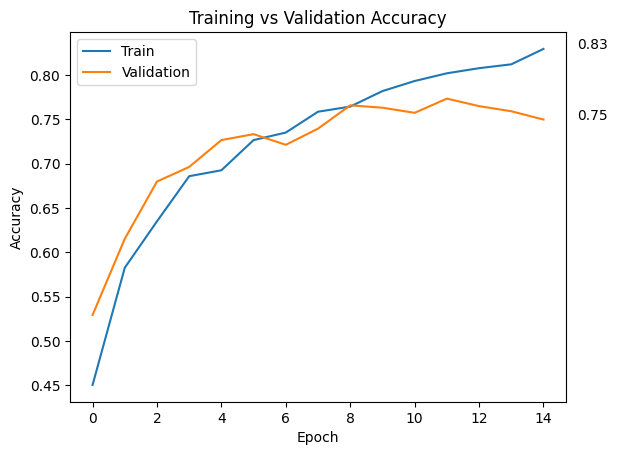

In [13]:
# train vs validation accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

# Part 3 Joyce: I found this on stackoverflow to show the numbers at the end
for var in (history.history['accuracy'], history.history['val_accuracy']):
  plt.annotate('%0.2f' % var[-1], xy=(1, var[-1]), xytext=(8, 0),
               xycoords=('axes fraction', 'data'), textcoords='offset points')

plt.show()

In [14]:
# metrics

# Predictions on test set
y_pred_prob = model.predict(test_data)

# True labels
y_true = test_data.classes

# convert probabilities to class predictions
y_pred = np.argmax(y_pred_prob, axis=1)
y_true_labels = y_true

accuracy = accuracy_score(y_true_labels, y_pred)
precision = precision_score(y_true_labels, y_pred, average='weighted')
recall = recall_score(y_true_labels, y_pred, average='weighted')
f1 = f1_score(y_true_labels, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nDetailed Classification Report:\n")
print(classification_report(y_true_labels, y_pred))

22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step
Accuracy: 0.744923405771286
Precision: 0.7623385726775266
Recall: 0.744923405771286
F1-score: 0.7473059324514674

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.63      0.78      0.70       438
           1       0.98      0.85      0.91       454
           2       0.73      0.73      0.73       481
           3       0.76      0.70      0.73       503
           4       0.65      0.81      0.72       455
           5       0.82      0.62      0.71       476

    accuracy                           0.74      2807
   macro avg       0.76      0.75      0.75      2807
weighted avg       0.76      0.74      0.75      2807



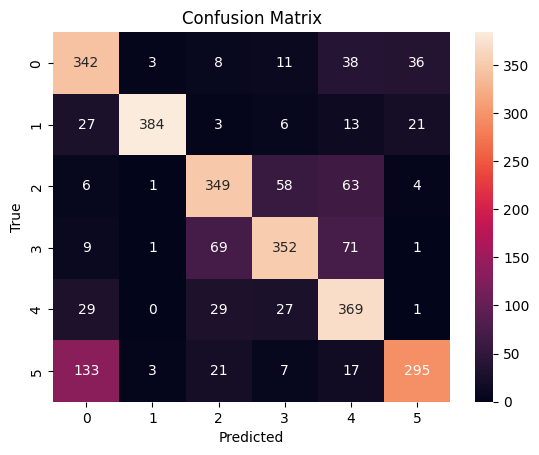

In [15]:
# confusion matrix

cm = confusion_matrix(y_true_labels, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step


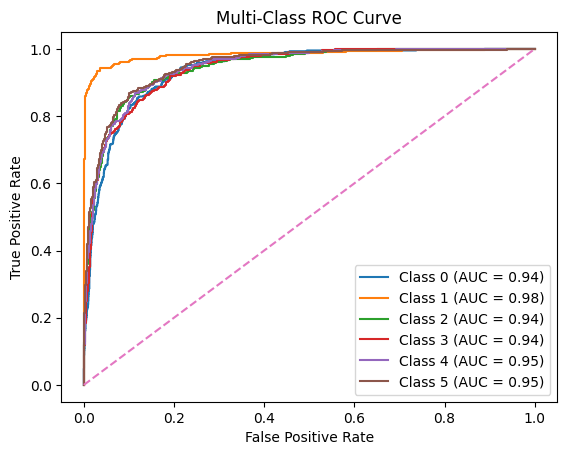

In [16]:
# multi-class ROC + AUC
n_classes = 6

# Predict probabilities
y_pred_prob = model.predict(test_data)

# Get true labels from test_data
# test_data.classes contains the integer labels for each image in the test set
y_true = tf.keras.utils.to_categorical(test_data.classes, num_classes=n_classes)

plt.figure()

for i in range(n_classes):
    # Ensure y_true is properly one-hot encoded for multi-class ROC
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend()
plt.show()

# 5. Model training

In [17]:
# Karol: TASK 3. PART I. IMPROVED MODEL
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, Model

inputs_imp = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Convolution block 1: different number of channels (32)  padding='same'
x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs_imp)
x = layers.BatchNormalization()(x) # Nowy hiperparametr: Batch Normalization
x = layers.MaxPooling2D((2, 2))(x)

# Convolution block 2: different number of channels (64)  padding='same'
x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

# Convolution block 3: different number of channels (128)  padding='same'
x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

# Dense layers
x = layers.Flatten()(x)
# Lowered neurons amount in a single Dense Layer (256)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x) # New hiperparameter: Dropout lowered to 0.3
x = layers.Dense(6, activation='softmax')(x)

improved_model = Model(inputs=inputs_imp, outputs=x)

# New hiperparameter: change of Learning Rate on 0.0008
custom_adam = Adam(learning_rate=0.0008)
improved_model.compile(
    optimizer=custom_adam,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

improved_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 42, 42, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 42, 42, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 42, 42, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 21, 21, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 10, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 915,142 (3.49 MB)

 Trainable params: 914,694 (3.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [18]:
# Karol: TASK 3. PART II. TRAINING IMPROVED MODEL
print("\n--- Training Improved Model ---")
history_imp = improved_model.fit(train_data, epochs=15, batch_size=64, validation_data=val_data)


--- Training Improved Model ---
Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 22s 221ms/step - accuracy: 0.4815 - loss: 1.8233 - val_accuracy: 0.2017 - val_loss: 3.5454
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - accuracy: 0.6943 - loss: 0.8178 - val_accuracy: 0.2280 - val_loss: 5.0076
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - accuracy: 0.7589 - loss: 0.6660 - val_accuracy: 0.3134 - val_loss: 4.3184
Epoch 4/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.8056 - loss: 0.5316 - val_accuracy: 0.2956 - val_loss: 4.2856
Epoch 5/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step - accuracy: 0.8158 - loss: 0.4997 - val_accuracy: 0.3406 - val_loss: 3.9288
Epoch 6/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - accuracy: 0.8418 - loss: 0.4305 - val_accuracy: 0.4599 - val_loss: 2.2945
Epoch 7/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 115ms/step - accuracy: 0.8575 - loss: 0.3874 - val_accuracy: 0.6318 - val_loss: 1.3437
Epoch 8/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.8934

# 6. Model evaluation

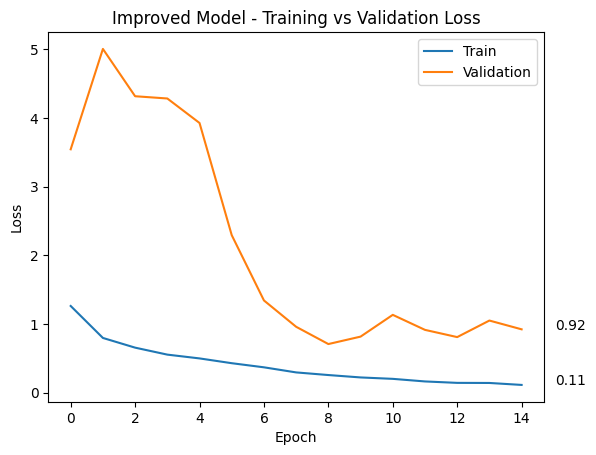

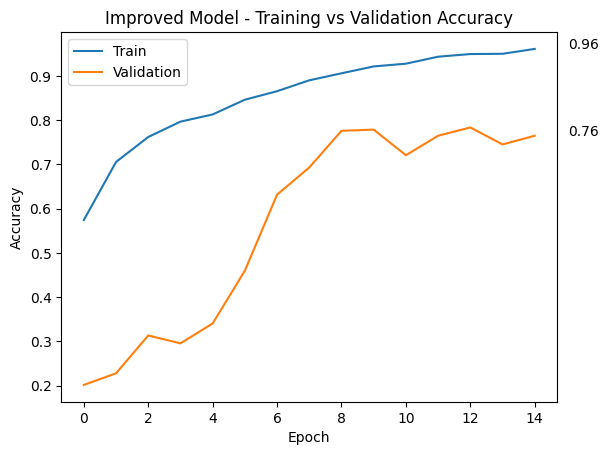

22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step
Improved Model - Accuracy: 0.7623797648735304
Improved Model - Precision: 0.7825882674329728
Improved Model - Recall: 0.7623797648735304
Improved Model - F1-score: 0.7617348317763226

Detailed Classification Report (Improved Model):

              precision    recall  f1-score   support

   buildings       0.71      0.70      0.71       438
      forest       0.98      0.78      0.87       454
     glacier       0.75      0.78      0.77       481
    mountain       0.87      0.58      0.69       503
         sea       0.67      0.89      0.76       455
      street       0.71      0.86      0.77       476

    accuracy                           0.76      2807
   macro avg       0.78      0.76      0.76      2807
weighted avg       0.78      0.76      0.76      2807



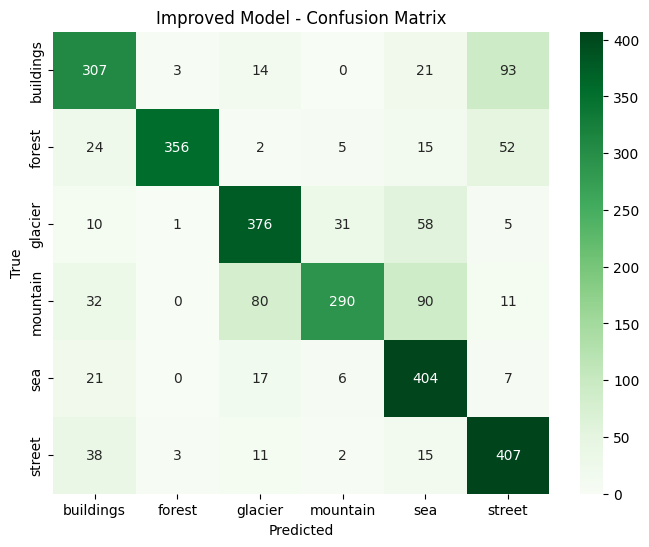

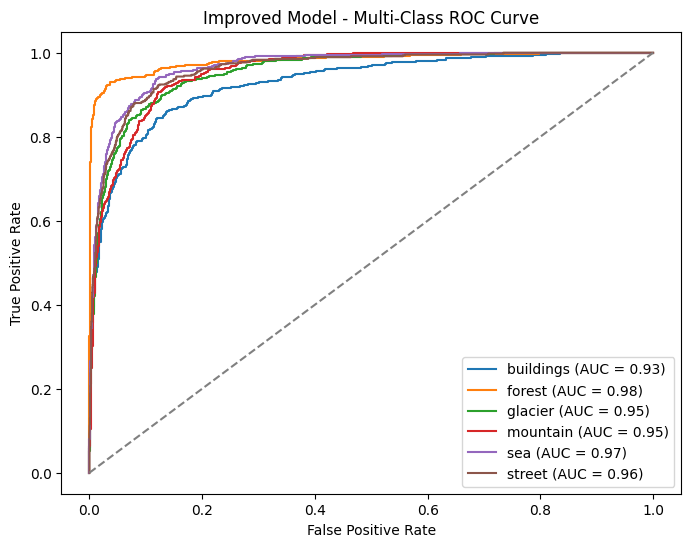

In [19]:
# --- KAROL: TASK 3. PART III. IMPROVED MODEL EVALUATION ---

# 1. W(Loss & Accuracy)
# train vs validation loss
plt.figure()
plt.plot(history_imp.history['loss'])
plt.plot(history_imp.history['val_loss'])
plt.title('Improved Model - Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
for var in (history_imp.history['loss'], history_imp.history['val_loss']):
  plt.annotate('%0.2f' % var[-1], xy=(1, var[-1]), xytext=(8, 0),
               xycoords=('axes fraction', 'data'), textcoords='offset points')
plt.show()

# train vs validation accuracy
plt.figure()
plt.plot(history_imp.history['accuracy'])
plt.plot(history_imp.history['val_accuracy'])
plt.title('Improved Model - Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
for var in (history_imp.history['accuracy'], history_imp.history['val_accuracy']):
  plt.annotate('%0.2f' % var[-1], xy=(1, var[-1]), xytext=(8, 0),
               xycoords=('axes fraction', 'data'), textcoords='offset points')
plt.show()

# 2. Evaluation on the test set

test_data.reset()
y_pred_prob_imp = improved_model.predict(test_data)
y_pred_imp = np.argmax(y_pred_prob_imp, axis=1)

# 3. Metrics
accuracy_imp = accuracy_score(y_true_labels, y_pred_imp)
precision_imp = precision_score(y_true_labels, y_pred_imp, average='weighted')
recall_imp = recall_score(y_true_labels, y_pred_imp, average='weighted')
f1_imp = f1_score(y_true_labels, y_pred_imp, average='weighted')

print("Improved Model - Accuracy:", accuracy_imp)
print("Improved Model - Precision:", precision_imp)
print("Improved Model - Recall:", recall_imp)
print("Improved Model - F1-score:", f1_imp)

print("\nDetailed Classification Report (Improved Model):\n")
print(classification_report(y_true_labels, y_pred_imp, target_names=CLASS_LABELS))

# 4. Confusion matrix
cm_imp = confusion_matrix(y_true_labels, y_pred_imp)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_imp, annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS)
plt.title('Improved Model - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# 5. Multi-class ROC + AUC
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr_imp, tpr_imp, _ = roc_curve(y_true[:, i], y_pred_prob_imp[:, i])
    roc_auc_imp = auc(fpr_imp, tpr_imp)
    plt.plot(fpr_imp, tpr_imp, label=f'{CLASS_LABELS[i]} (AUC = {roc_auc_imp:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Improved Model - Multi-Class ROC Curve')
plt.legend()
plt.show()

# 7. Transfer Learning – ResNet50

In [26]:
# --- TIES: TASK 4. PART 1. Load Pretrained ResNet50 ---

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

print("Base model loaded successfully.")

Base model loaded successfully.


In [27]:
# --- TIES: TASK 4. PART 2. Freeze Base Model Layers ---

for layer in base_model.layers:
    layer.trainable = False

print("Total layers:", len(base_model.layers))
print("Trainable layers after freezing:",
      sum([layer.trainable for layer in base_model.layers]))

Total layers: 175
Trainable layers after freezing: 0


In [28]:
# --- TIES: TASK 4. PART 3. Add Custom Fully Connected Layers ---

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(len(CLASS_LABELS), activation='softmax')(x)

model_resnet = models.Model(inputs=base_model.input, outputs=output)

model_resnet.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 42, 42, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 48, 48, 3) │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 21, 21,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 21, 21,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 21, 21,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 23, 23,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 11, 11,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 11, 11,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 11, 11,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 11, 11,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 11, 11,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 11, 11,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 11, 11,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 11, 11,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 11, 11,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 11, 11,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 11, 11,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [29]:
# --- TIES: TASK 4. PART 4. Compile Model ---

model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [30]:
# --- TIES: TASK 4. PART 5. Train ResNet50 Transfer Model ---

history_resnet = model_resnet.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 29s 273ms/step - accuracy: 0.2376 - loss: 1.7860 - val_accuracy: 0.4061 - val_loss: 1.5045
Epoch 2/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 132ms/step - accuracy: 0.4192 - loss: 1.4925 - val_accuracy: 0.4840 - val_loss: 1.3501
Epoch 3/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step - accuracy: 0.4553 - loss: 1.3687 - val_accuracy: 0.4942 - val_loss: 1.2802
Epoch 4/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 130ms/step - accuracy: 0.4742 - loss: 1.3087 - val_accuracy: 0.5098 - val_loss: 1.2431
Epoch 5/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - accuracy: 0.4777 - loss: 1.2806 - val_accuracy: 0.5245 - val_loss: 1.2059
Epoch 6/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 135ms/step - accuracy: 0.5025 - loss: 1.2550 - val_accuracy: 0.5361 - val_loss: 1.1861
Epoch 7/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 123ms/step - accuracy: 0.5062 - loss: 1.2291 - val_accuracy: 0.5459 - val_loss: 1.1630
Epoch 8/15
71/71 ━━━━━━━━━━━━━━━━━━━━ 9s 133ms/step - accuracy: 0.5201 - loss: 1.2159 - val_accuracy:

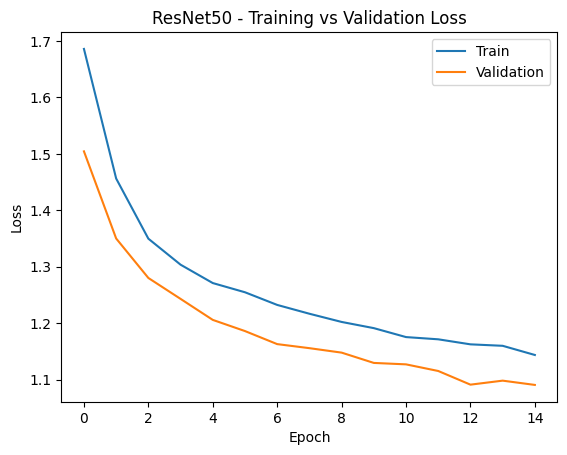

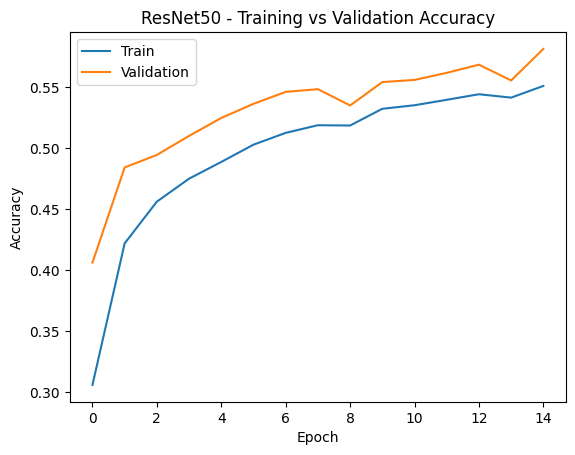

In [31]:
# --- TIES: TASK 4. PART 6. Training Curves ---

import matplotlib.pyplot as plt

# Loss
plt.figure()
plt.plot(history_resnet.history['loss'])
plt.plot(history_resnet.history['val_loss'])
plt.title("ResNet50 - Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

# Accuracy
plt.figure()
plt.plot(history_resnet.history['accuracy'])
plt.plot(history_resnet.history['val_accuracy'])
plt.title("ResNet50 - Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [32]:
# --- TIES: TASK 4. PART 7. Evaluation on Test Set ---

test_loss, test_accuracy = model_resnet.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 244ms/step - accuracy: 0.5621 - loss: 1.1218
Test Loss: 1.1040688753128052
Test Accuracy: 0.573922336101532


22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 464ms/step

Classification Report:

              precision    recall  f1-score   support

   buildings       0.64      0.38      0.48       438
      forest       0.74      0.81      0.77       454
     glacier       0.43      0.66      0.52       481
    mountain       0.59      0.52      0.55       503
         sea       0.50      0.48      0.49       455
      street       0.64      0.59      0.62       476

    accuracy                           0.57      2807
   macro avg       0.59      0.57      0.57      2807
weighted avg       0.59      0.57      0.57      2807



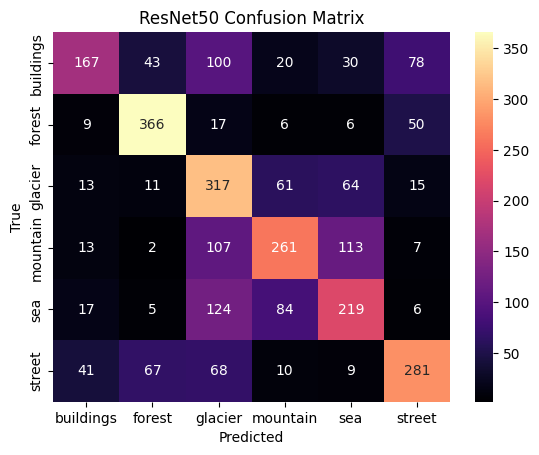

In [33]:
# --- TIES: TASK 4. PART 8. Performance Metrics & Confusion Matrix ---

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

# Predictions
y_pred_prob = model_resnet.predict(test_data)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = test_data.classes

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_LABELS))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='magma',
            xticklabels=CLASS_LABELS,
            yticklabels=CLASS_LABELS)
plt.title("ResNet50 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

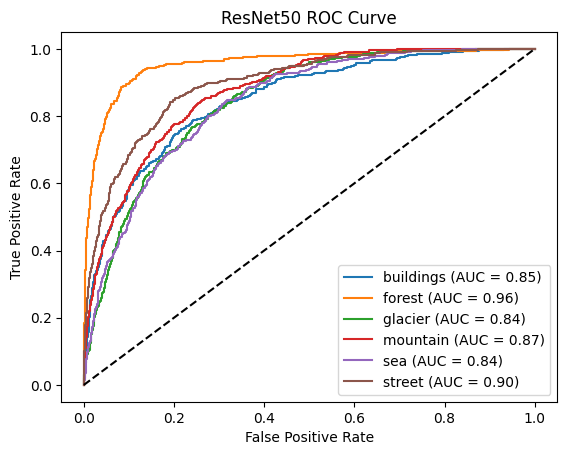

In [34]:
# --- TIES: TASK 4. PART 9. ROC Curve & AUC ---

from sklearn.preprocessing import label_binarize

# Binarize labels for multiclass ROC
y_true_bin = label_binarize(y_true, classes=range(len(CLASS_LABELS)))

plt.figure()

for i in range(len(CLASS_LABELS)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{CLASS_LABELS[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ResNet50 ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()